In [2]:
import whisper
import librosa
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:

video_file = "videos/tips_interview_1080p.mp4" # Ganti dengan nama file video Anda

# video_file = "/mnt/c/DATA D/aa-kuliah/skripsi/DATASET/first-impressions/train/ZYrFfvp7_Mo.000.mp4"

# 1. Path A: Whisper (Teks + Timestamps)
# model = whisper.load_model("medium")
# result = model.transcribe(video_file, word_timestamps=True)

# 2. Path B: Librosa (Intonasi/Pitch)
y, sr = librosa.load(video_file)
pitches, magnitudes = librosa.piptrack(y=y, sr=sr)

# result['text']

/home/zero/aa-kuliah/skripsi/AIVIEW/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_961/1121488898.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(video_file)
/home/zero/aa-kuliah/skripsi/AIVIEW/venv/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


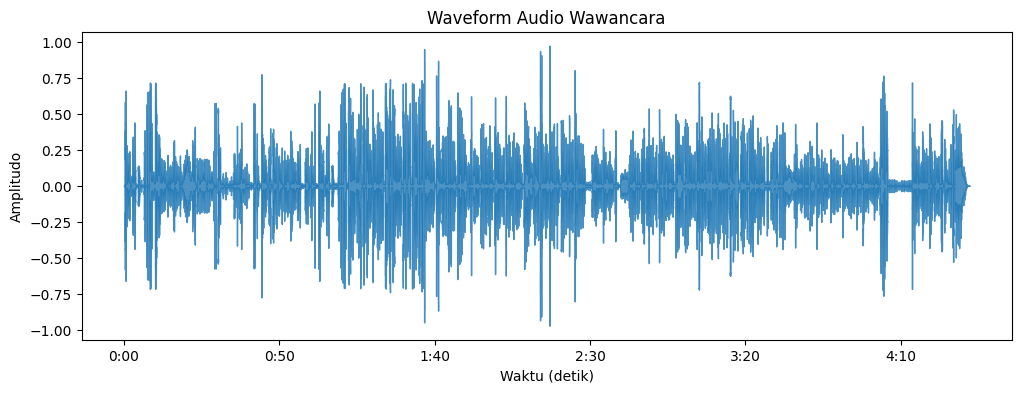

In [4]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr, alpha=0.8)
plt.title('Waveform Audio Wawancara')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')
plt.show()

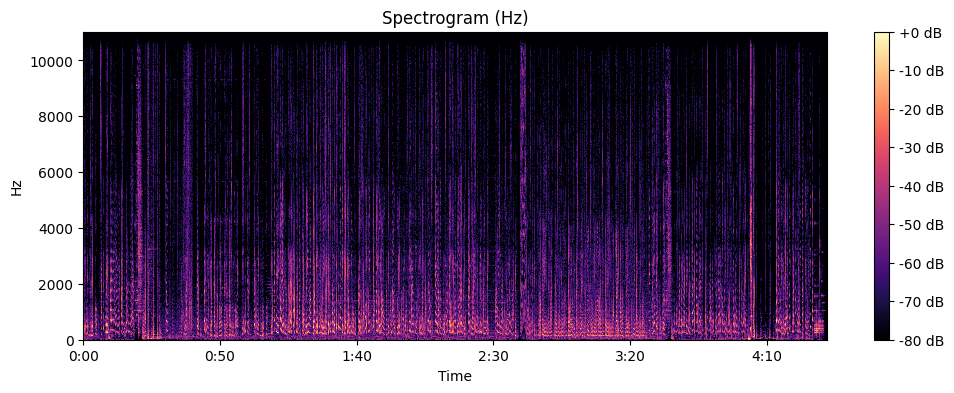

In [5]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

# Plot Spectrogram
plt.figure(figsize=(12, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram (Hz)')
plt.show()

In [ ]:
# Hitung Mel-spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)

# Plot
plt.figure(figsize=(12, 4))
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-Spectrogram (Skala Pendengaran Manusia)')
plt.tight_layout()
plt.show()

In [ ]:
# Simple function to get the average pitch at a specific time
def get_pitch_at_time(time_sec, pitches, sr):
    frame = librosa.time_to_frames(time_sec, sr=sr)
    pitch = pitches[:, frame].max()
    return pitch

# 3. Synchronize and print results
for segment in result['segments']:
    start = segment['start']
    text = segment['text']
    pitch_val = get_pitch_at_time(start, pitches, sr)
    
    print(f"[{start}s] Text: {text} | Pitch: {pitch_val:.2f}Hz")

In [ ]:
segments = result['segments']
for segment in segments:
    start = segment['start']
    end = segment['end']
    text = segment['text']
    
    # Get pitch values for the segment duration
    pitch_values = []
    for t in np.arange(start, end, 0.1):  # Check every 0.1 seconds
        pitch_val = get_pitch_at_time(t, pitches, sr)
        pitch_values.append(pitch_val)
    
    avg_pitch = np.mean(pitch_values) if pitch_values else 0
    print(f"[{start:.2f}s - {end:.2f}s] Text: {text} | Average Pitch: {avg_pitch:.2f}Hz")

This version is for more accurate and more representative expressions from audio to text

In [ ]:
# 1. Hitung Baseline (sama seperti sebelumnya agar adaptif terhadap suara subjek)
valid_pitches = pitches[pitches > 0]
mean_pitch = np.mean(valid_pitches) if len(valid_pitches) > 0 else 0
std_pitch = np.std(valid_pitches) if len(valid_pitches) > 0 else 0
high_threshold = mean_pitch + (0.5 * std_pitch) # Sedikit diperketat agar tidak semua kata jadi CAPS

def get_mean_pitch_in_range(start_time, end_time, pitches, sr):
    start_frame = librosa.time_to_frames(start_time, sr=sr)
    end_frame = librosa.time_to_frames(end_time, sr=sr)
    
    # Ambil irisan pitch pada rentang waktu kata tersebut
    word_pitches = pitches[:, start_frame:end_frame]
    valid_word_pitches = word_pitches[word_pitches > 0]
    
    return np.mean(valid_word_pitches) if len(valid_word_pitches) > 0 else 0

final_transcript = []

# 2. Proses per segment, lalu per kata (Word-level)
for segment in result['segments']:
    segment_words = []
    
    for word_data in segment['words']:
        word_text = word_data['word']
        start = word_data['start']
        end = word_data['end']
        
        # Ambil pitch khusus untuk kata ini
        word_pitch = get_mean_pitch_in_range(start, end, pitches, sr)
        
        # Logika CAPS jika pitch melebihi ambang batas
        if word_pitch > high_threshold:
            processed_word = word_text.upper()
        else:
            processed_word = word_text.lower() # atau biarkan normal
            
        segment_words.append(processed_word)
    
    # Gabungkan kembali menjadi kalimat
    full_sentence = "".join(segment_words).strip()
    final_transcript.append(full_sentence)
    print(f"[{segment['start']:.2f}s] {full_sentence}")

# 3. Hasil akhir untuk dimasukkan ke VADER
complete_text = " ".join(final_transcript)

In [6]:
from sentence_transformers import SentenceTransformer

# 1. Load a pretrained Sentence Transformer model
# model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1010.43it/s]


In [7]:
sentence1 = "Kami memohon maaf atas keterlambatan pengiriman dokumen tersebut dikarenakan adanya kendala teknis yang tidak terduga."
sentence2 = "Kami mohon maaf atas keterlambatan pengiriman dokumen tersebut karena adanya kendala teknis yang tidak terduga."


# sentence1 = "Kecerdasan buatan kini mampu membantu dokter mendiagnosis penyakit dengan akurasi yang sangat tinggi."
# sentence2 = "Hutan hujan tropis di Kalimantan merupakan rumah bagi ribuan spesies flora dan fauna yang langka"
# sentence1 = "Artificial intelligence is now able to help doctors diagnose diseases with very high accuracy."
# sentence2 = "The tropical rainforests of Kalimantan are home to thousands of rare species of flora and fauna."

embedding_sentence1 = model.encode(sentence1)
print(embedding_sentence1.shape)
embedding_sentence2 = model.encode(sentence2)
print(embedding_sentence2.shape)

# 3. Calculate the embedding similarities
similarities = model.similarity(embedding_sentence1, embedding_sentence2)
print(similarities)
# tensor([[1.0000, 0.6660, 0.1046],
#         [0.6660, 1.0000, 0.1411],
#         [0.1046, 0.1411, 1.0000]])

(384,)
(384,)
tensor([[0.9875]])
